In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import shapiro, levene, spearmanr, kendalltau, f_oneway

df = pd.read_csv("../data/processed/all_data_cleaned.csv")

df.head()


,City,Pollution Index,Exp Pollution Index,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index,Traffic Index,...,Time Exp. Index,Inefficiency Index,CO2�Emission Index,Year,Log Pollution,Pollution per Minute,Purchasing Power Category,Unnamed: 3,Unnamed: 7,Unnamed: 6
0,"Kolkata, India",145.5,210.6,32.0,8.8,23.6,35.1,21.0,49.3,355.4,...,39925.1,580.0,19684.0,2012,4.980176,1.960916,Low,NaN,NaN,NaN
1,"Tehran, Iran",140.8,204.2,62.4,31.0,51.1,56.6,49.0,45.7,328.2,...,38296.2,351.3,9714.0,2012,4.947340,1.915646,Low,NaN,NaN,NaN
2,"Bucharest, Romania",140.7,198.4,51.0,15.3,38.1,39.8,41.8,36.1,86.9,...,489.2,78.3,2752.2,2012,4.946630,4.078261,Low,NaN,NaN,NaN
3,"Shanghai, China",140.2,197.4,54.2,29.9,45.4,51.6,42.6,47.0,73.6,...,173.7,70.9,2608.0,2012,4.943070,4.493590,Low,NaN,NaN,NaN
4,"Athens, Greece",140.0,199.3,96.5,20.8,69.3,71.9,97.6,48.4,112.8,...,1260.6,161.4,4045.0,2012,4.941642,3.617571,Low,NaN,NaN,NaN


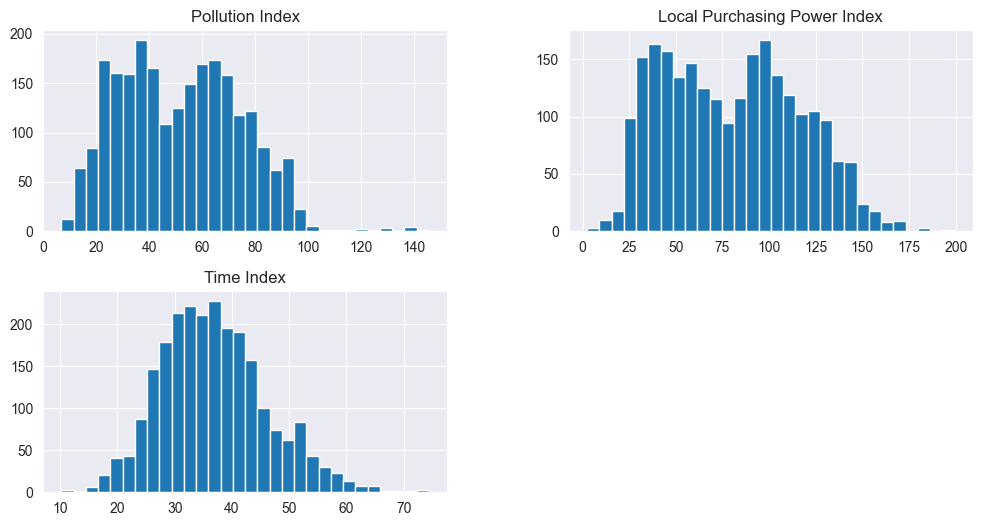

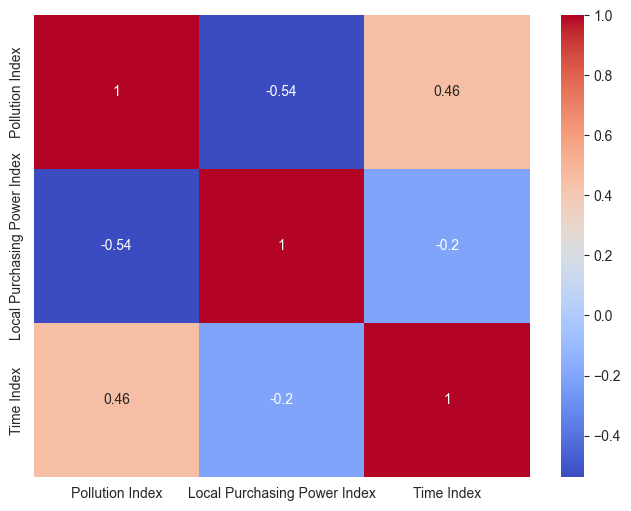

In [2]:
df[["Pollution Index", "Local Purchasing Power Index", "Time Index"]].hist(bins=30, figsize=(12,6))
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df[["Pollution Index","Local Purchasing Power Index","Time Index"]].corr(), annot=True, cmap="coolwarm")
plt.show()


In [3]:
for col in ["Pollution Index","Local Purchasing Power Index","Time Index"]:
    stat, p = shapiro(df[col].dropna())
    print(f"{col}: stat={stat:.3f}, p={p:.3f} -> {'Normal' if p>0.05 else 'Not Normal'}")

Pollution Index: stat=0.974, p=0.000 -> Not Normal
Local Purchasing Power Index: stat=0.971, p=0.000 -> Not Normal
Time Index: stat=0.985, p=0.000 -> Not Normal


In [4]:
high_pp = df[df["Local Purchasing Power Index"] > df["Local Purchasing Power Index"].median()]["Pollution Index"]
low_pp  = df[df["Local Purchasing Power Index"] <= df["Local Purchasing Power Index"].median()]["Pollution Index"]

stat, p = levene(high_pp, low_pp)
print(f"Levene test (Purchasing Power groups): stat={stat:.3f}, p={p:.3f}")

Levene test (Purchasing Power groups): stat=10.033, p=0.002


In [5]:
pearson_corr = df["Local Purchasing Power Index"].corr(df["Pollution Index"], method="pearson")
spearman_corr, _ = spearmanr(df["Local Purchasing Power Index"], df["Pollution Index"])
kendall_corr, _ = kendalltau(df["Local Purchasing Power Index"], df["Pollution Index"])

print(f"Pearson: {pearson_corr:.3f}, Spearman: {spearman_corr:.3f}, Kendall: {kendall_corr:.3f}")

Pearson: -0.539, Spearman: -0.559, Kendall: -0.380


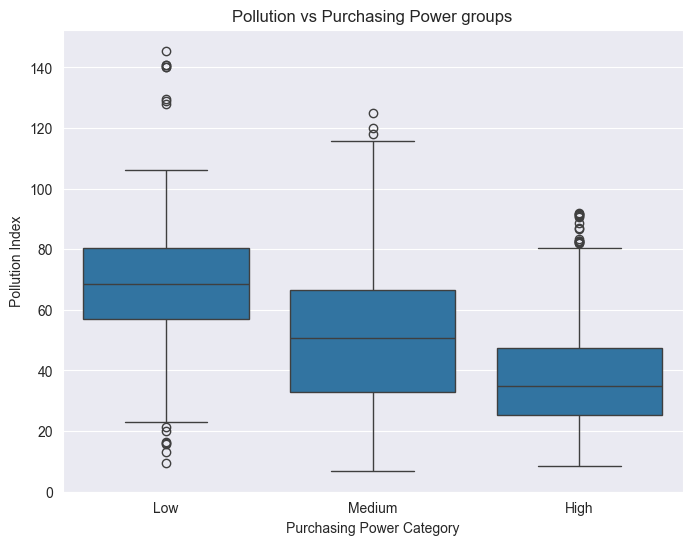

In [6]:
plt.figure(figsize=(8,6))
sns.boxplot(x="Purchasing Power Category", y="Pollution Index", data=df)
plt.title("Pollution vs Purchasing Power groups")
plt.show()